# 01. 선형회귀모델

## 1-1. 단일선형회귀

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
# 1. 데이터 생성
x = torch.linspace(0,10,100).view(-1, 1) # 입력데이터
y = 3 * x + 2 + torch.randn(100, 1) * 2  
# y = x**2 + 0.5 * x + torch.randn(1000, 1) * 10 # 레이블

# 2. 모델 정의
class LinearRegressionModel(nn.Module):
  def __init__(self,):
    super().__init__()
    self.linear = nn.Linear(1,1) # 입력 1개, 출력 1개

  def forward(self, x):
    return self.linear(x)
  
model = LinearRegressionModel()

# 3. 손실함수, 옵티마이저 정의
criterion = nn.MSELoss() # 평균 제곱 오차
optimizer = optim.SGD(model.parameters(), lr=0.001) # 확률적 경사 하강법

# 4. 가중치 업데이트
epochs = 1000 # 학습 반복 횟수
losses = []

for epoch in range(epochs):
  optimizer.zero_grad() # 기울기 초기화
  outputs = model(x) # 예측값 계산
  loss = criterion(outputs, y) # 손실 계산
  loss.backward() # 역전파
  optimizer.step() # 가중치 업데이트

  losses.append(loss.item())

  # 100번에 한번씩 로그 출력
  if (epoch + 1) % 100 == 0: 
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item(): .4f}")

# 5. 결과 시각화
plt.figure(figsize=(10,5))

# 손실 감소 그래프
plt.subplot(1, 2, 1)
# plt.ylim(0,5)
plt.plot(losses)
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# 데이터와 예측 결과
plt.subplot(1, 2, 2)
plt.scatter(x.numpy(), y.numpy(), label="Original Data")
plt.plot(x.numpy(), model(x).detach().numpy(), color="r", label="Fitted Line")
plt.title("Linear Regression Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

print("Model Parameters:")
for name, param in model.named_parameters():
  print(f"{name}: {param.data}")

Epoch [100 / 2000], Loss:  6527.1250
Epoch [200 / 2000], Loss:  5409.1807
Epoch [300 / 2000], Loss:  4771.9170
Epoch [400 / 2000], Loss:  4494.9976
Epoch [500 / 2000], Loss:  4007.8481
Epoch [600 / 2000], Loss:  3902.9631
Epoch [700 / 2000], Loss:  3749.8538
Epoch [800 / 2000], Loss:  3594.4460
Epoch [900 / 2000], Loss:  3464.0413
Epoch [1000 / 2000], Loss:  3350.6038
Epoch [1100 / 2000], Loss:  3262.6353
Epoch [1200 / 2000], Loss:  3170.4976
Epoch [1300 / 2000], Loss:  3095.5974
Epoch [1400 / 2000], Loss:  3029.8582
Epoch [1500 / 2000], Loss:  2962.4478
Epoch [1600 / 2000], Loss:  2893.3818
Epoch [1700 / 2000], Loss:  2838.5020
Epoch [1800 / 2000], Loss:  2769.8984
Epoch [1900 / 2000], Loss:  2717.6375
Epoch [2000 / 2000], Loss:  2679.7529


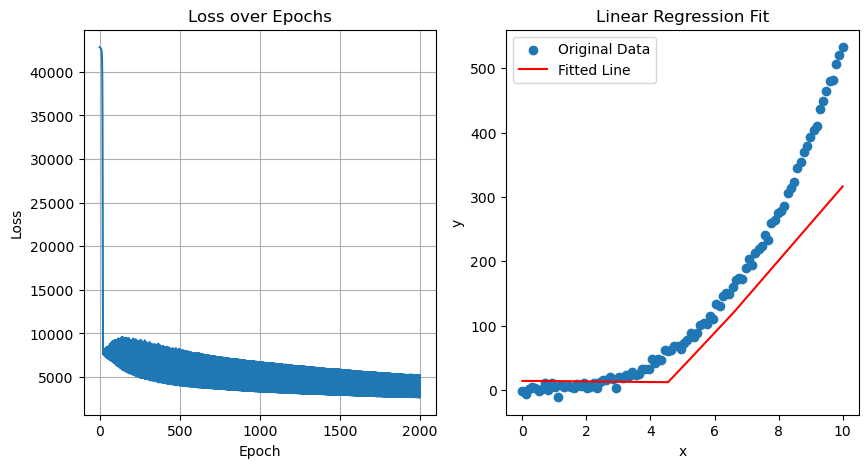

Model Parameters:
model.0.weight: tensor([[-0.4759],
        [ 0.7188],
        [-0.7994],
        [ 2.8060],
        [-0.1701],
        [-0.9491],
        [ 1.9469],
        [-0.1760],
        [ 4.2333],
        [-0.4254]])
model.0.bias: tensor([ -0.6949,  -2.9090,  -0.4315, -12.6481,   3.2116,   0.9405,  -8.8329,
          0.2273, -18.6252,  -0.0575])
model.2.weight: tensor([[ 0.1011,  0.1362, -0.2092,  0.0063,  0.0211, -0.3062, -0.2917,  0.2510,
         -0.1253, -0.2539],
        [ 0.0104, -0.0201,  0.0059, -0.1596,  0.1063, -0.0837, -0.0919, -0.0782,
          0.0863, -0.2235],
        [ 0.0702, -0.2302,  0.1815, -0.0405,  0.3389,  0.1846,  0.0240,  0.0904,
         -0.0479, -0.2307],
        [ 0.1867,  0.4392, -0.1890,  1.6985, -0.1285, -0.0073,  1.1788,  0.2744,
          2.5099, -0.1526],
        [-0.0953, -0.0497,  0.0603,  0.0038, -0.2762, -0.2999,  0.1360,  0.0093,
          0.1870,  0.1054],
        [ 0.0799, -0.1410,  0.0678,  0.0812, -0.3464,  0.1929, -0.0299,  0.2722,
  

In [26]:
# 1. 입출력 정의
x = torch.linspace(0, 10, 100).view(-1, 1)
y = 0.5 * (x ** 3) + 0.3 * (x ** 2) + 2 + torch.randn(100, 1) * 5 # label

# 2. 모델 정의
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    # self.hidden = nn.Linear(1,10)
    # self.sigmoid = nn.ReLU()
    # self.output = nn.Linear(10,1)
    self.model = nn.Sequential(
      nn.Linear(1,10),
      nn.ReLU(),
      nn.Linear(10,10),
      nn.ReLU(),
      nn.Linear(10,1)
    )

  def forward(self,x):
    # x = self.hidden(x)
    # x = self.sigmoid(x)
    # x = self.output(x)
    return self.model(x)
  
model = LinearRegressionModel() # 모델 객체 생성
  
# 3. 손실함수정의
criterion = nn.MSELoss() # 평균 제곱 오차

# 4. 가중치 업데이트
optimizer = optim.SGD(model.parameters(), lr=0.0001) # 확률적 경사 하강법
epochs = 2000 # 학습 반복 횟수
losses = []

for epoch in range(epochs):
  optimizer.zero_grad() # 기울기 초기화
  outputs = model(x) # 예측값 계산 → model의 forward 함수 실행
  loss = criterion(outputs, y) # 손실 계산
  loss.backward() # 역전파
  optimizer.step() # 가중치 업데이트

  losses.append(loss.item()) # 손실함수 그래프 그리기용

  # 학습 로그 출력
  if (epoch + 1) % 100 == 0:
    print(f"Epoch [{epoch+1} / {epochs}], Loss: {loss.item(): .4f}")

# 5. 결과 시각화
plt.figure(figsize=(10,5))

# 손실 감소 그래프
plt.subplot(1, 2, 1)
# plt.ylim(0,5)
plt.plot(losses)
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# 데이터와 예측 결과
plt.subplot(1, 2, 2)
plt.scatter(x.numpy(), y.numpy(), label="Original Data")
plt.plot(x.numpy(), model(x).detach().numpy(), color="r", label="Fitted Line")
plt.title("Linear Regression Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

print("Model Parameters:")
for name, param in model.named_parameters():
  print(f"{name}: {param.data}")

Epoch [100/1000], Loss:  3.5439
Epoch [200/1000], Loss:  3.5034
Epoch [300/1000], Loss:  3.4669
Epoch [400/1000], Loss:  3.4337
Epoch [500/1000], Loss:  3.4036
Epoch [600/1000], Loss:  3.3763
Epoch [700/1000], Loss:  3.3515
Epoch [800/1000], Loss:  3.3289
Epoch [900/1000], Loss:  3.3085
Epoch [1000/1000], Loss:  3.2900
최종 Test Loss:  3.0213


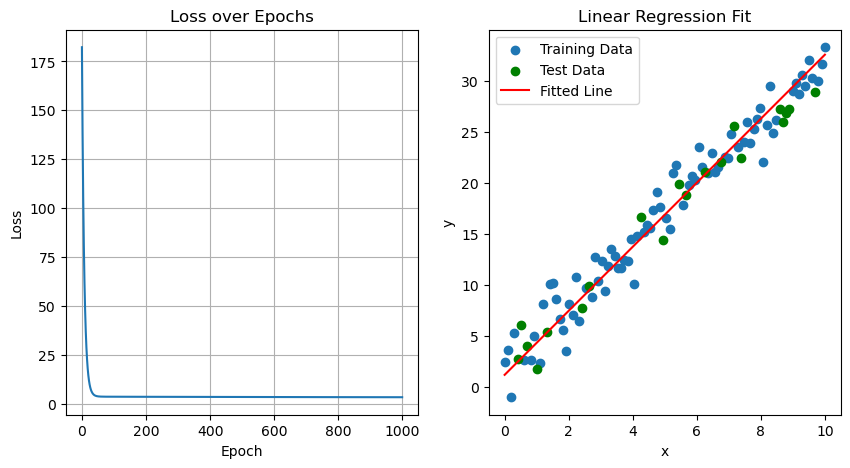

In [31]:
# 1. 데이터 생성
x = torch.linspace(0,10,100).view(-1, 1) # 입력데이터
y = 3 * x + 2 + torch.randn(100, 1) * 2  

# Train / Test set 분리 (8:2로 분리)
num_train = int(len(x) * 0.8)
indices = torch.randperm(len(x))
train_idx, test_idx = indices[:num_train], indices[num_train:]

x_train, y_train = x[train_idx], y[train_idx]
x_test, y_test = x[test_idx], y[test_idx]

# 2. 모델 정의
class LinearRegressionModel(nn.Module):
  def __init__(self,):
    super().__init__()
    self.linear = nn.Linear(1,1) # 입력 1개, 출력 1개

  def forward(self, x):
    return self.linear(x)
  
model = LinearRegressionModel()

# 3. 손실함수, 옵티마이저 정의
criterion = nn.MSELoss() # 평균 제곱 오차
optimizer = optim.SGD(model.parameters(), lr=0.001) # 확률적 경사 하강법

# 4. 가중치 업데이트
epochs = 1000 # 학습 반복 횟수
losses = []

for epoch in range(epochs):
  optimizer.zero_grad() # 기울기 초기화
  outputs = model(x_train) # 예측값 계산
  loss = criterion(outputs, y_train) # 손실 계산
  loss.backward() # 역전파
  optimizer.step() # 가중치 업데이트

  losses.append(loss.item())

  # 100번에 한번씩 로그 출력
  if (epoch + 1) % 100 == 0: 
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item(): .4f}")

# 5. 테스트 데이터 평가
with torch.no_grad():
  test_output = model(x_test)
  test_loss = criterion(test_output, y_test)
print(f"최종 Test Loss: {test_loss.item(): .4f}")

# 6. 결과 시각화
plt.figure(figsize=(10,5))

# 손실 감소 그래프
plt.subplot(1, 2, 1)
# plt.ylim(0,5)
plt.plot(losses)
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# 데이터와 예측 결과
plt.subplot(1, 2, 2)
plt.scatter(x_train.numpy(), y_train.numpy(), label="Training Data")
plt.scatter(x_test.numpy(), y_test.numpy(), label="Test Data", color="g")
plt.plot(x.numpy(), model(x).detach().numpy(), color="r", label="Fitted Line")
plt.title("Linear Regression Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

# print("Model Parameters:")
# for name, param in model.named_parameters():
#   print(f"{name}: {param.data}")

## 1-2. 다중선형회귀

Epoch [100/1000], Loss:  3.0251
Epoch [200/1000], Loss:  2.7733
Epoch [300/1000], Loss:  2.6608
Epoch [400/1000], Loss:  2.5721
Epoch [500/1000], Loss:  2.5015
Epoch [600/1000], Loss:  2.4452
Epoch [700/1000], Loss:  2.4003
Epoch [800/1000], Loss:  2.3643
Epoch [900/1000], Loss:  2.3355
Epoch [1000/1000], Loss:  2.3122


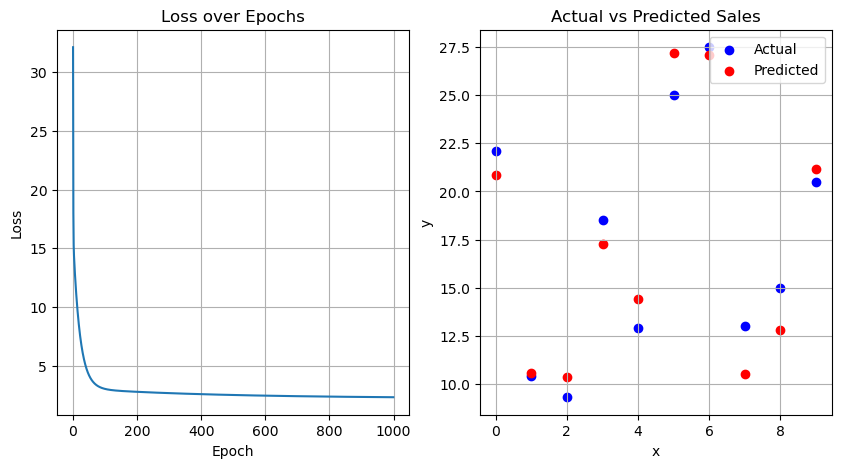

Model Parameters:
linear.weight: tensor([[ 0.2040,  0.4441, -0.0166]])
linear.bias: tensor([0.0732])


In [35]:
# 1. 데이터 입출력 정의
x = torch.tensor([[50.0, 25.0, 30.0],
                  [10.0, 20.0, 25.0],
                  [5.0, 22.0, 30.0],
                  [30.0, 26.0, 28.0],
                  [40.0, 15.0, 28.0],
                  [60.0, 35.0, 40.0],
                  [70.0, 30.0, 35.0],
                  [20.0, 15.0, 20.0],
                  [25.0, 18.0, 22.0],
                  [45.0, 28.0, 30.0]], dtype=torch.float32)

y = torch.tensor([[22.1], [10.4], [9.3], [18.5], [12.9], 
                  [25.0], [27.5], [13.0], [15.0], [20.5]], dtype=torch.float32)

# 2. 모델 정의
class MultipleLinearRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(3,1)

  def forward(self, x):
    return self.linear(x)
  
model = MultipleLinearRegression()

# 3. 손실함수 정의
criterion = nn.MSELoss()

# 4. 기울기 업데이트(학습)
optimizer = optim.SGD(model.parameters(), lr=0.0001)
epochs = 1000
losses = []

for epoch in range(epochs):
  optimizer.zero_grad()
  outputs = model(x)
  loss = criterion(outputs, y)
  loss.backward()
  optimizer.step()

  losses.append(loss.item())

  if (epoch + 1) % 100 == 0:
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item(): .4f}")

# 5. 결과 시각화
plt.figure(figsize=(10,5))

# 손실 감소 그래프
plt.subplot(1, 2, 1)
# plt.ylim(0,5)
plt.plot(losses)
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# 데이터와 예측 결과
predicted = model(x).detach().numpy()
actual = y.numpy()

plt.subplot(1, 2, 2)
plt.scatter(range(len(actual)), actual, label="Actual", color="b")
plt.scatter(range(len(predicted)), predicted, label="Predicted", color="r")
plt.title("Actual vs Predicted Sales")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()

plt.show()

print("Model Parameters:")
for name, param in model.named_parameters():
  print(f"{name}: {param.data}")
